# 1. import thư viện

In [1]:
import torch
import torch.nn as nn
import pandas as pd 
from torchvision import transforms
import os
from PIL import Image
from pathlib import Path
from torch.utils.data import DataLoader, random_split, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import shutil
import random
print(torch.__version__)


2.10.0+cu128


# 2. CRNN Model

In [2]:
# https://github.com/meijieru/crnn.pytorch/blob/master/models/crnn.py


class BidirectionalLSTM(nn.Module):

    def __init__(self, nIn, nHidden, nOut):
        super(BidirectionalLSTM, self).__init__()

        self.rnn = nn.LSTM(nIn, nHidden, bidirectional=True)
        self.embedding = nn.Linear(nHidden * 2, nOut)

    def forward(self, input):
        recurrent, _ = self.rnn(input)
        T, b, h = recurrent.size()
        t_rec = recurrent.view(T * b, h)

        output = self.embedding(t_rec)  # [T * b, nOut]
        output = output.view(T, b, -1)

        return output


class CRNN(nn.Module):

    def __init__(self, imgH, nc, nclass, nh, n_rnn=2, leakyRelu=False):
        super(CRNN, self).__init__()
        assert imgH % 16 == 0, 'imgH has to be a multiple of 16'

        ks = [3, 3, 3, 3, 3, 3, 2]
        ps = [1, 1, 1, 1, 1, 1, 0]
        ss = [1, 1, 1, 1, 1, 1, 1]
        nm = [64, 128, 256, 256, 512, 512, 512]

        cnn = nn.Sequential()

        def convRelu(i, batchNormalization=False):
            nIn = nc if i == 0 else nm[i - 1]
            nOut = nm[i]
            cnn.add_module('conv{0}'.format(i),
                           nn.Conv2d(nIn, nOut, ks[i], ss[i], ps[i]))
            if batchNormalization:
                cnn.add_module('batchnorm{0}'.format(i), nn.BatchNorm2d(nOut))
            if leakyRelu:
                cnn.add_module('relu{0}'.format(i),
                               nn.LeakyReLU(0.2, inplace=True))
            else:
                cnn.add_module('relu{0}'.format(i), nn.ReLU(True))

        convRelu(0)
        cnn.add_module('pooling{0}'.format(0), nn.MaxPool2d(2, 2))  # 64x16x64
        convRelu(1)
        cnn.add_module('pooling{0}'.format(1), nn.MaxPool2d(2, 2))  # 128x8x32
        convRelu(2, True)
        convRelu(3)
        cnn.add_module('pooling{0}'.format(2),
                       nn.MaxPool2d((2, 2), (2, 1), (0, 1)))  # 256x4x16
        convRelu(4, True)
        convRelu(5)
        cnn.add_module('pooling{0}'.format(3),
                       nn.MaxPool2d((2, 2), (2, 1), (0, 1)))  # 512x2x16
        convRelu(6, True)  # 512x1x16

        self.cnn = cnn
        self.rnn = nn.Sequential(
            BidirectionalLSTM(512, nh, nh),
            BidirectionalLSTM(nh, nh, nclass))

    def forward(self, input):
        # conv features
        conv = self.cnn(input)
        b, c, h, w = conv.size()
        assert h == 1, "the height of conv must be 1"
        conv = conv.squeeze(2)
        conv = conv.permute(2, 0, 1)  # [w, b, c]

        # rnn features
        output = self.rnn(conv)

        return output

# 3. Xây dựng dataset

In [3]:
class MeterRecognitionDataset(Dataset):
    def __init__(self, csv_file, image_dir, img_width=100, img_height=32, rotate_180=False):
        self.image_dir = image_dir
        self.df = pd.read_csv(csv_file, dtype={"label": str})
        self.img_width = img_width
        self.img_height = img_height
        self.rotate_180 = rotate_180
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_height, img_width)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __getitem__(self, index):
        row = self.df.iloc[index]
        file_name = row['filename']
        label = str(row['label'])
        image = Image.open(os.path.join(self.image_dir, file_name)).convert('L')
        
        if self.rotate_180:
            image = image.rotate(180)
            
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.df)

# 4. Kiểm tra dataset

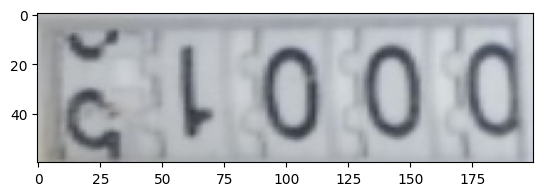

In [4]:
img = Image.open("/kaggle/input/datasets/lmgiathnh/recognition-5-6-digits/recognition_merge_2/train/images/train_0_5d.jpg")
plt.imshow(img)
plt.show()

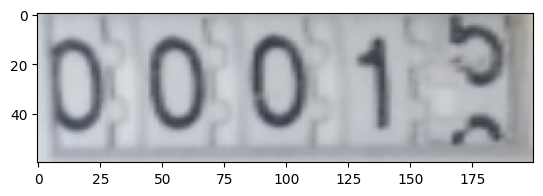

In [5]:
plt.imshow(img.rotate(180))
plt.show()

In [6]:
def collate_fn(batch):

    images = []
    labels = []

    for image, label in batch:

        images.append(image)
        labels.append(label)

    images = torch.stack(images)

    return (
        images,
        labels,
    )

# 6. Train mô hình

In [7]:

# =========================================================
# CONFIG
# =========================================================

ROOT = Path("/kaggle/input/datasets/lmgiathnh/recognition-5-6-digits")

DATA_DIR = (
    ROOT
    / "recognition_merge_2"
)

TRAIN_CSV = DATA_DIR / "train" / "train_labels.csv"
TRAIN_IMAGES = DATA_DIR / "train" / "images"

VAL_CSV = DATA_DIR / "val" / "val_labels.csv"
VAL_IMAGES = DATA_DIR / "val" / "images"

SAVE_DIR = Path("/kaggle/working/weights")
SAVE_DIR.mkdir(exist_ok=True)

IMG_WIDTH = 100
IMG_HEIGHT = 32
NCLASS = 11  # 0-9 + CTC blank
NH = 256

BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 1e-3
NUM_WORKERS = 0
PATIENCE = 30

In [8]:

# =========================================================
# DEVICE
# =========================================================

device = torch.device("cuda")

print(f"Device: {device}")
print(f"Train CSV: {TRAIN_CSV}")
print(f"Val CSV: {VAL_CSV}")

Device: cuda
Train CSV: /kaggle/input/datasets/lmgiathnh/recognition-5-6-digits/recognition_merge_2/train/train_labels.csv
Val CSV: /kaggle/input/datasets/lmgiathnh/recognition-5-6-digits/recognition_merge_2/val/val_labels.csv


In [9]:

# =========================================================
# DATASET & DATALOADER
# =========================================================

train_dataset = MeterRecognitionDataset(
    csv_file=TRAIN_CSV,
    image_dir=TRAIN_IMAGES,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    rotate_180=False
)

val_dataset = MeterRecognitionDataset(
    csv_file=VAL_CSV,
    image_dir=VAL_IMAGES,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    rotate_180=False
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train samples: 12948
Val samples: 1439
Train batches: 203
Val batches: 23


In [10]:

# =========================================================
# MODEL
# =========================================================

model = CRNN(
    imgH=IMG_HEIGHT,
    nc=1,
    nclass=NCLASS,
    nh=NH
).to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 8,317,963


In [11]:
# =========================================================
# LOSS & OPTIMIZER
# =========================================================

criterion = nn.CTCLoss(blank=10, reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [12]:

# =========================================================
# TRAINING LOOP
# =========================================================
patience_counter = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device)

        # Convert labels to tensor
        target_tensor = []
        target_lengths = []
        for label in labels:
            target_tensor.extend([int(c) for c in label])
            target_lengths.append(len(label))

        target_tensor = torch.tensor(target_tensor, dtype=torch.long).to(device)
        target_lengths = torch.tensor(target_lengths, dtype=torch.long).to(device)

        # Forward
        logits = model(images)
        log_probs = logits.log_softmax(2)
        input_lengths = torch.full(
            size=(logits.size(1),),
            fill_value=logits.size(0),
            dtype=torch.long
        ).to(device)

        loss = criterion(log_probs, target_tensor, input_lengths, target_lengths)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # -------------------------
    # VAL
    # -------------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device)

            # Convert labels to tensor
            target_tensor = []
            target_lengths = []

            for label in labels:
                # Chuyển từng ký tự thành số nguyên và nối vào danh sách chung
                target_tensor.extend([int(c) for c in label])
                # Lưu lại độ dài thực tế của nhãn này
                target_lengths.append(len(label))

            # Chuyển về Tensor 1D
            target_tensor = torch.tensor(target_tensor, dtype=torch.long).to(device)
            target_lengths = torch.tensor(target_lengths, dtype=torch.long).to(device)

            # Forward
            logits = model(images)
            log_probs = logits.log_softmax(2)
            input_lengths = torch.full(
                size=(logits.size(1),),
                fill_value=logits.size(0),
                dtype=torch.long
            ).to(device)

        loss = criterion(log_probs, target_tensor, input_lengths, target_lengths).to(device)
        val_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # -------------------------
    # SAVE BEST
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, SAVE_DIR / "best_model.pth")
        patience_counter = 0
        print(f"Saved best model with val_loss: {val_loss:.4f}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break

    # -------------------------
    # LOG
    # -------------------------
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print()

print("Training completed!")


Epoch 1/200 [Val]: 100%|██████████| 23/23 [00:15<00:00,  1.47it/s]


Saved best model with val_loss: 0.0776
Epoch 1/200
  Train Loss: 2.0499
  Val Loss: 0.0776



Epoch 2/200 [Val]: 100%|██████████| 23/23 [00:03<00:00,  6.20it/s]


Saved best model with val_loss: 0.0681
Epoch 2/200
  Train Loss: 1.6335
  Val Loss: 0.0681



Epoch 3/200 [Val]: 100%|██████████| 23/23 [00:03<00:00,  6.50it/s]


...

Epoch 77/200
  Train Loss: 0.0040
  Val Loss: 0.0084



Epoch 78/200 [Val]: 100%|██████████| 23/23 [00:03<00:00,  6.36it/s]


Epoch 78/200
  Train Loss: 0.0035
  Val Loss: 0.0094



Epoch 79/200 [Val]: 100%|██████████| 23/23 [00:03<00:00,  6.45it/s]

Early stopping triggered
Training completed!


# 7. Biểu đồ train/loss

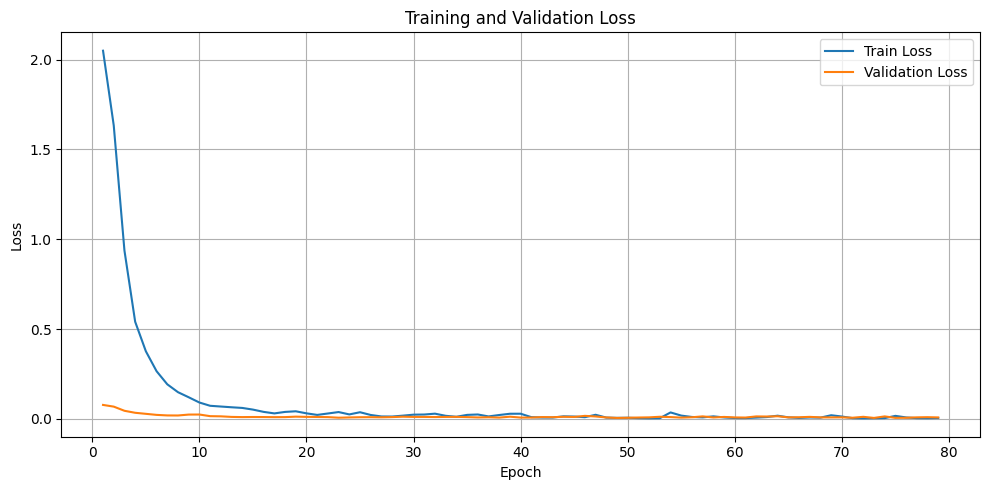

In [13]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 8. Dự đoán

In [14]:
TEST_CSV = DATA_DIR / "test" / "test_labels.csv"
TEST_IMAGES = DATA_DIR / "test" / "images"

test_dataset = MeterRecognitionDataset(
    csv_file=TEST_CSV,
    image_dir=TEST_IMAGES,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    rotate_180=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# =========================================================
# LOAD BEST MODEL
# =========================================================

checkpoint = torch.load(
    SAVE_DIR / "best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


# =========================================================
# GREEDY CTC DECODE
# =========================================================

def greedy_decode(output):
    # output: [T, B, C]

    pred = output.argmax(dim=2)
    pred = pred.permute(1, 0)

    results = []

    for sequence in pred:

        chars = []
        previous = 10

        for index in sequence:

            index = index.item()

            # CTC blank
            if index == 10:
                previous = index
                continue

            # Remove repeated characters
            if index == previous:
                continue

            chars.append(str(index))
            previous = index

        results.append("".join(chars))

    return results



def levenshtein_stats(pred, gt):
    """
    Return:
        TP = correctly predicted characters
        FP = incorrectly predicted / extra characters
        FN = missed characters
        edit_distance
    """

    n = len(gt)
    m = len(pred)

    # DP matrix
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    # Build DP
    for i in range(1, n + 1):
        for j in range(1, m + 1):

            if gt[i - 1] == pred[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,       # deletion
                dp[i][j - 1] + 1,       # insertion
                dp[i - 1][j - 1] + cost # substitution
            )

    # Backtracking
    i = n
    j = m

    TP = 0
    FP = 0
    FN = 0

    while i > 0 or j > 0:

        # Match
        if (
            i > 0
            and j > 0
            and gt[i - 1] == pred[j - 1]
            and dp[i][j] == dp[i - 1][j - 1]
        ):
            TP += 1
            i -= 1
            j -= 1

        # Substitution
        elif (
            i > 0
            and j > 0
            and dp[i][j] == dp[i - 1][j - 1] + 1
        ):
            FP += 1
            FN += 1
            i -= 1
            j -= 1

        # Deletion
        elif (
            i > 0
            and dp[i][j] == dp[i - 1][j] + 1
        ):
            FN += 1
            i -= 1

        # Insertion
        else:
            FP += 1
            j -= 1

    return TP, FP, FN, dp[n][m]


# =========================================================
# TEST
# =========================================================

sequence_correct = 0
total = 0

total_tp = 0
total_fp = 0
total_fn = 0

total_edit_distance = 0
total_gt_chars = 0


with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)

        output = model(images)

        predictions = greedy_decode(output)

        for pred, gt in zip(predictions, labels):

            # -------------------------------------------------
            # Exact Sequence Accuracy
            # -------------------------------------------------

            if pred == gt:
                sequence_correct += 1

            total += 1

            # -------------------------------------------------
            # Character-level metrics
            # -------------------------------------------------

            tp, fp, fn, edit_distance = levenshtein_stats(
                pred,
                gt
            )

            total_tp += tp
            total_fp += fp
            total_fn += fn

            total_edit_distance += edit_distance
            total_gt_chars += len(gt)


# =========================================================
# METRICS
# =========================================================

sequence_accuracy = sequence_correct / total

precision = (
    total_tp / (total_tp + total_fp)
    if (total_tp + total_fp) > 0
    else 0
)

recall = (
    total_tp / (total_tp + total_fn)
    if (total_tp + total_fn) > 0
    else 0
)

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

character_accuracy = (
    total_tp / total_gt_chars
    if total_gt_chars > 0
    else 0
)

cer = (
    total_edit_distance / total_gt_chars
    if total_gt_chars > 0
    else 0
)


# =========================================================
# PRINT RESULTS
# =========================================================

print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Test samples           : {total}")

print(f"Sequence Accuracy      : {sequence_accuracy:.4f}")
print(f"Sequence Accuracy (%)  : {sequence_accuracy * 100:.2f}%")

print(f"\nCharacter Accuracy     : {character_accuracy:.4f}")
print(f"Character Accuracy (%) : {character_accuracy * 100:.2f}%")

print(f"\nPrecision              : {precision:.4f}")
print(f"Recall                 : {recall:.4f}")
print(f"F1-score               : {f1:.4f}")

print(f"\nCER                    : {cer:.4f}")
print(f"CER (%)                : {cer * 100:.2f}%")

print(f"\nEdit Distance          : {total_edit_distance}")

print("=" * 60)

Testing: 100%|██████████| 38/38 [00:26<00:00,  1.42it/s]


TEST RESULTS
Test samples           : 2400
Sequence Accuracy      : 0.9363
Sequence Accuracy (%)  : 93.62%

Character Accuracy     : 0.9852
Character Accuracy (%) : 98.52%

Precision              : 0.9884
Recall                 : 0.9852
F1-score               : 0.9868

CER                    : 0.0163
CER (%)                : 1.63%

Edit Distance          : 202


# 9. Dự đoán và visualize 2 ảnh 

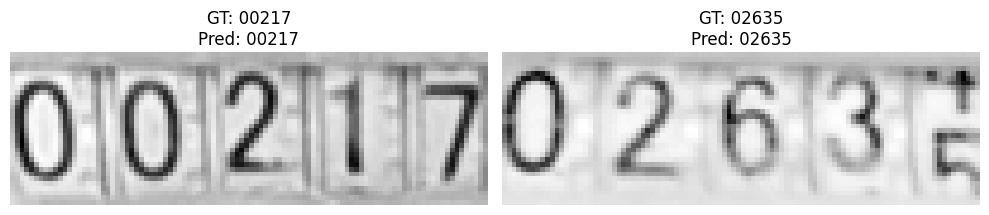

In [15]:
import random
import matplotlib.pyplot as plt

# Random 2 ảnh
indices = random.sample(range(len(test_dataset)), 2)

model.eval()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

with torch.no_grad():
    for ax, idx in zip(axes, indices):

        sample = test_dataset[idx]

        # Dataset có thể trả 2 hoặc 3 giá trị
        image, gt = sample[:2]

        # Predict
        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = greedy_decode(output)[0]

        # Denormalize để hiển thị
        show_image = image.squeeze().cpu() * 0.5 + 0.5

        ax.imshow(
            show_image,
            cmap="gray"
        )

        ax.set_title(
            f"GT: {gt}\nPred: {pred}"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()